<a href="https://colab.research.google.com/github/mitparekh8263/CV-2026-H11/blob/main/Practical_03/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread('/content/tiger.jpg', cv2.IMREAD_GRAYSCALE)
img.shape

(364, 549)

We load the image in grayscale mode so that we work with a single intensity channel (values 0 to 255).

cmap='gray' displays the image in shades of gray. The axes show pixel coordinates.

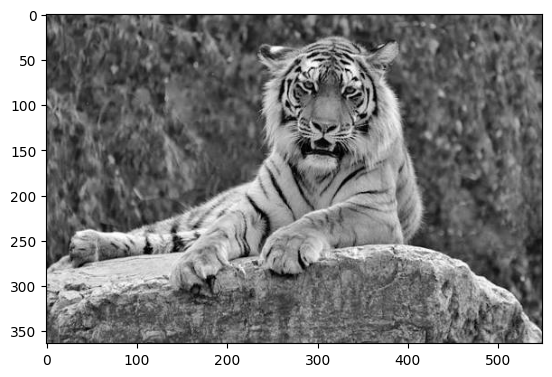

In [4]:
plt.imshow(img, cmap='gray')
plt.show()

Matplotlib doesn't know the data is a grayscale image, so it applies its default colorful palette unless you force cmap='gray'.

In [5]:
def add_salt_pepper_noise(img, prob = 0.3) :
  noisy_img = img.copy()

  random = np.random.rand(*img.shape)
  noisy_img[random < prob/2] = 0
  noisy_img[random > 1 - prob/2] = 255

  return noisy_img

explanation behind adding s/p noise given in exp 2

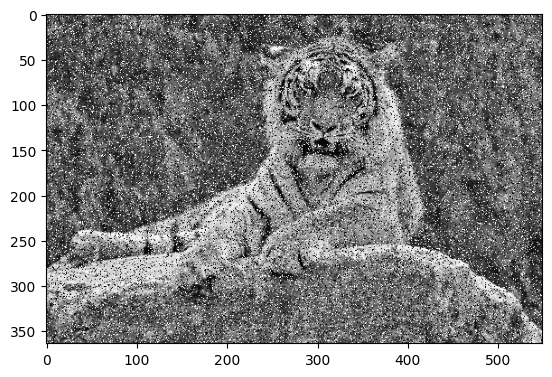

In [6]:
prob = 0.2

noisy_img = add_salt_pepper_noise(img, prob)
plt.imshow(noisy_img, cmap='gray')
plt.show()

In [7]:
def mean_filter(img, k=3, s=1):
    hi, wi = img.shape[:2] # we use img.shape[:2] to safely ignore any extra dimensions (like color channels) just in case a color image is accidentally passed
    p = k // 2 # int division
    padded_img = np.pad(img, p, mode='reflect') # pad extra p rows at the top/bottom and p cols at the left/right. mode='reflect' mirrors the image at the borders (e.g., pixel at -1 takes the value of pixel at 1)

    # o/p size calculation of convoluted matrix
    ho = (hi + 2*p - k) // s + 1
    wo = (wi + 2*p - k) // s + 1

    output = np.zeros((ho, wo), dtype=np.uint8) # matrix initially filled with zeros, but later values change from 0 to 255

    for i in range(ho):
        for j in range(wo):
            # i*s and j*s = starting position of the window on the padded image (jumping by stride s for each output pixel)
            window = padded_img[i*s:i*s+k, j*s:j*s+k] # Start at (i*s, j*s) and take k × k block from padded image
            output[i, j] = np.round(np.mean(window)).astype(np.uint8) # convert float rounded off mean to 8-bit int value (from 0 to 255) and put in o/p matrix

    return output

In [8]:
def median_filter(img, k=3, s=1):
    hi, wi = img.shape # we use img.shape directly because we strictly expect a 2D array (as per the original code). Both ultimately store the image height in hi and width in wi
    p = k // 2
    padded_img = np.pad(img, p, mode='reflect')

    ho = (hi + 2*p - k) // s + 1
    wo = (wi + 2*p - k) // s + 1

    output = np.zeros((ho, wo), dtype=img.dtype)

    for i in range(ho):
        for j in range(wo):
            window = padded_img[i*s:i*s+k, j*s:j*s+k]
            output[i, j] = np.median(window) # Flattens the 2D window into a 1D array, sorts it, and picks the exact middle value. Since k is odd, the median is always an existing integer from the window. .astype(np.uint8) is implicit

    return output

Both filters take the image, a kernel size k (must be odd) and a stride s (step size).

Padding of p = k//2 is added using reflection to handle borders.

The output dimensions are computed as:
ho = (hi + 2*p - k) // s + 1 and similarly for wo.
This gives the number of positions where the kernel fits when moving by stride s.

For each output pixel, we extract a k × k window from the padded image, compute the mean (rounded to nearest integer) or median, and assign it.

**Example – Mean filter on the noisy 5 × 5 patch (k=3, s=1)**

Take the noisy patch:

[120   0 125 255 130]

[122 124 126 129 255]

[125   0 180 132 137]

[128 130 255 135 137]

[  0 133 135 255 140]

We want to compute the output pixel at position (1,1) (0 ‑ based) – the centre of the 3 × 3 window covering rows 0 to 2 and cols 0 to 2:

[120   0 125]

[122 124 126]

[125   0 180]

Mean = (120+0+125+122+124+126+125+0+180) / 9 = 922 / 9 ≈ 102.44 → round to 102.
So the output at that position becomes 102.

**Median filter on the same window:**

Sort the 9 values: [0, 0, 120, 122, 124, 125, 125, 126, 180] → median is the 5th value = 124.
Thus the median filter replaces the centre with 124.

Notice that the median filter rejects the extreme salt (255) and pepper (0) values, while the mean is pulled down by the zeros. This is why median filtering is much better for s/p noise – it preserves edges and does not introduce new intermediate values.

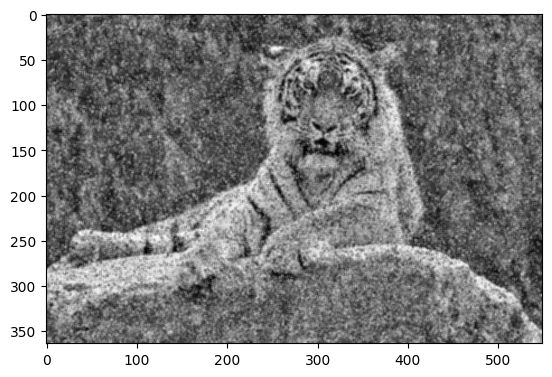

In [9]:
mean_clean_img = mean_filter(noisy_img) # at k = 3, s = 1
plt.imshow(mean_clean_img, cmap='gray')
plt.show()

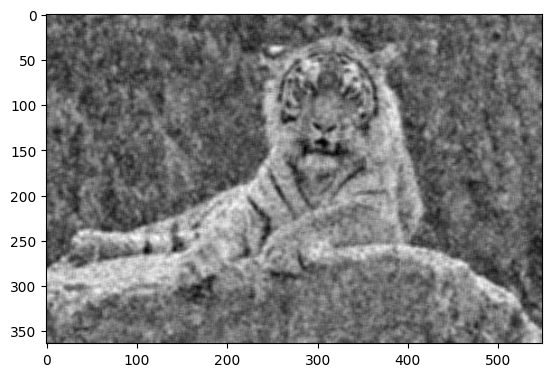

In [10]:
mean_clean_img = mean_filter(noisy_img, 5) # at k = 5, s = 1
plt.imshow(mean_clean_img, cmap='gray')
plt.show()

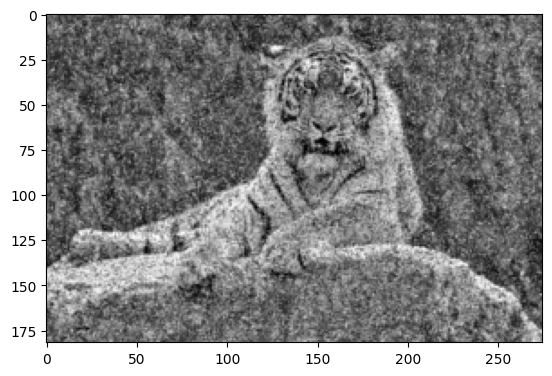

In [11]:
mean_clean_img = mean_filter(noisy_img, 3, 2) # at k = 3, s = 2
plt.imshow(mean_clean_img, cmap='gray')
plt.show()

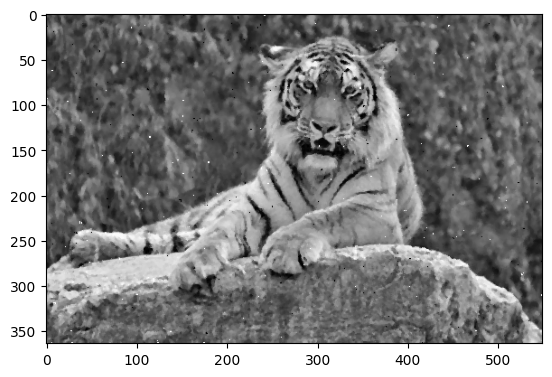

In [12]:
median_clean_img = median_filter(noisy_img) # at k = 3, s = 1
plt.imshow(median_clean_img, cmap='gray')
plt.show()

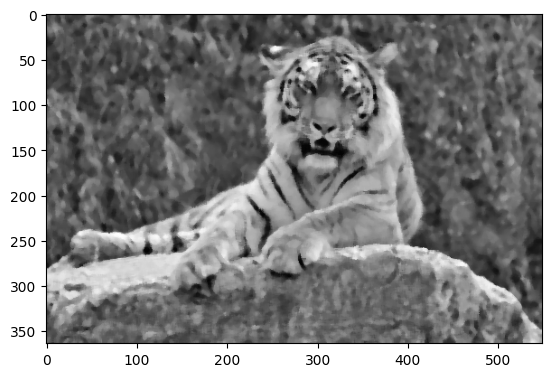

In [13]:
median_clean_img = median_filter(noisy_img, 5) # at k = 5, s = 1
plt.imshow(median_clean_img, cmap='gray')
plt.show()

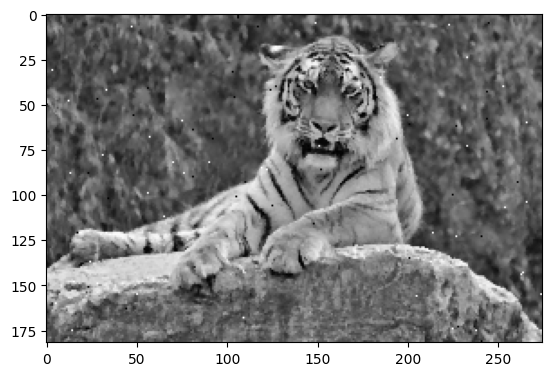

In [14]:
median_clean_img = median_filter(noisy_img, 3, 2) # at k = 3, s = 1
plt.imshow(median_clean_img, cmap='gray')
plt.show()

**Note:**

Median > Mean for Salt & Pepper: The Median filter completely eliminates salt (255) and pepper (0) noise by selecting the middle sorted value, whereas the Mean filter fails badly because averaging includes the extreme noisy values, creating unwanted grey smudges.

Kernel Size (k) Trade-off: Increasing k removes more noise but increases blur and loses fine details (edges, textures). For salt-and-pepper noise, k=3 is the optimal balance; k=5 over-smooths the image unnecessarily.

Stride (s) Controls Output Size: s=1 keeps the image the same size (preserves resolution) and is mandatory for pure denoising. s>1 (e.g., s=2) downsamples the image (halves the dimensions), making it smaller and pixelated—this is meant for shrinking, not cleaning noise.

Best Practice Recommendation: For removing salt-and-pepper noise, always use median_filter(img, k=3, s=1). This gives you the cleanest result with maximum detail preservation and original resolution intact.

**some common padding modes:**

'constant': Pads with a single uniform value (default is 0).

'edge': Pads using the closest edge values of the original array (e.g., the edge pixel is copied beyond the boundary).

'reflect': Pads by mirroring the internal values without repeating the edge value.

'symmetric': Pads by mirroring the internal values while including the edge value (e.g., [a, b, c] → [c, b, a, b, c]).

'wrap': Pads by wrapping the values around from the opposite side of the array (copies pixels from the opposite edge).

'linear_ramp' : Creates a linear gradient between the edge pixel and a specified end value.